Aprendizado de variedades (Manifold Learning) com fluxo de clusterização distribuída por tipo de característica é mais informativo do que o UMAP para conjuntos de dados clínicos tabulares

Importando as Libraries

In [1]:
import sys
import os

# Ajusta o caminho para encontrar os módulos do FDC
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

print(f"Diretório atual: {current_dir}")
print(f"Diretório pai adicionado: {parent_dir}")

Diretório atual: c:\Católica\IA\Clinical-database\FDC_Intermediate_Dimension\Jupyter notebooks
Diretório pai adicionado: c:\Católica\IA\Clinical-database\FDC_Intermediate_Dimension


In [2]:
import subprocess
import sys

# Instala pacotes necessários que podem estar faltando
packages_to_install = ['yellowbrick']

for package in packages_to_install:
    try:
        __import__(package)
        print(f"✓ {package} já está instalado")
    except ImportError:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✓ {package} instalado com sucesso")

✓ yellowbrick já está instalado


In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
import math
import umap.umap_ as umap
%config InlineBackend.figure_format = 'svg'

In [4]:
from cluster_val import *

Importando os dados

In [5]:
np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
data_with_target=pd.read_csv('../Datasets/preprocessed_migraine_data.csv')

In [6]:
np.random.seed(42)
data=data_with_target.sample(frac=1) #Emabaralha o dataset
np.random.seed(42)
i=[x for x in range(400)]

data.set_index(pd.Series(i), inplace=True)

In [7]:
data.drop(['Unnamed: 0','Type'],axis=1,inplace=True)

UMAP nos dados originais

In [8]:
from fdc.fdc import feature_clustering

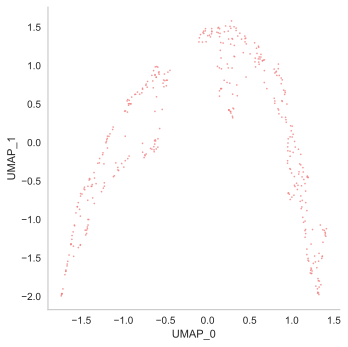

In [9]:
umap_emb=feature_clustering(15,0.1,'euclidean',data,True)

Silhouette_score e Dunn index para os clusters do UMAP extraidos usando clustering K-means

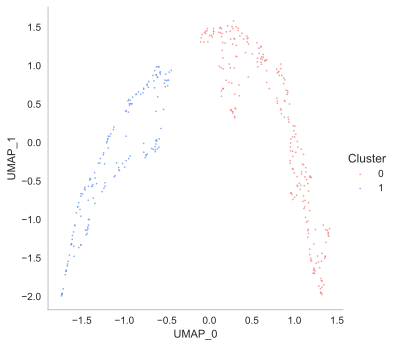

In [10]:
from fdc.clustering import Clustering

umap_clustering=Clustering(umap_emb,umap_emb,True)
umap_cluster_list,umap_cluster_counts=umap_clustering.K_means(2)

In [11]:
from sklearn import metrics
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score

In [12]:
silhouette_score(umap_emb, umap_cluster_list, metric='euclidean')

0.5032854083336068

Visualizar Silhouette score (Pode-se escolher o números de clusters baseados no resultado)

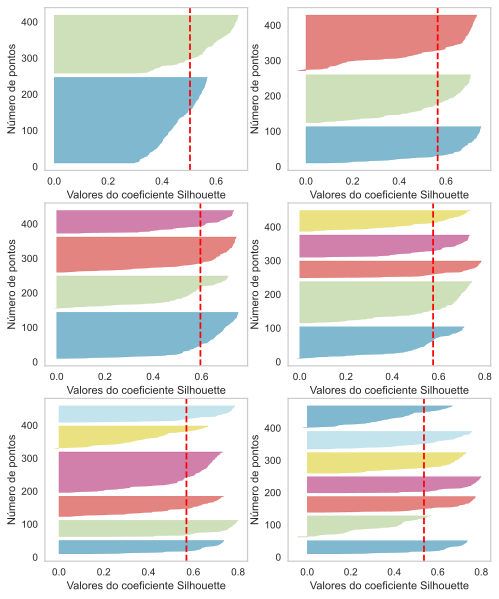

In [13]:
Silhouette_visual(umap_emb)

Elbow plot para o embedding

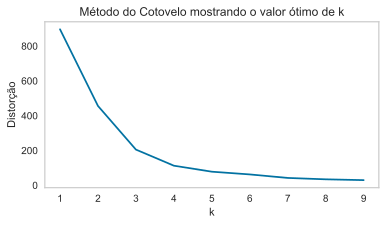

In [14]:
elbow_plot(umap_emb)

In [15]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list))

0.13629724205568197

Silhouette_score e Dunn index para os clusters UMAP extraídos usando clustering aglomerativo

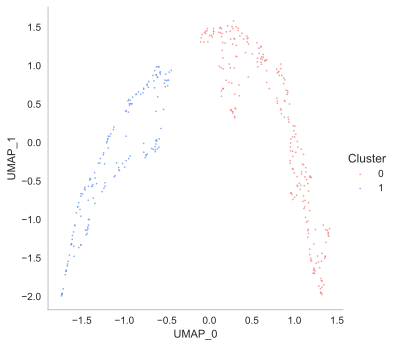

In [16]:
umap_cluster_list_agglo,umap_cluster_counts_agglo=umap_clustering.Agglomerative(2,'euclidean','ward')

In [17]:
silhouette_score(umap_emb, umap_cluster_list_agglo, metric='euclidean')

0.5032854083336068

In [18]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list_agglo))

0.13629724205568197

Silhouette_score e Dunn index para os clusters UMAP extraídos usando clustering do DBSCAN

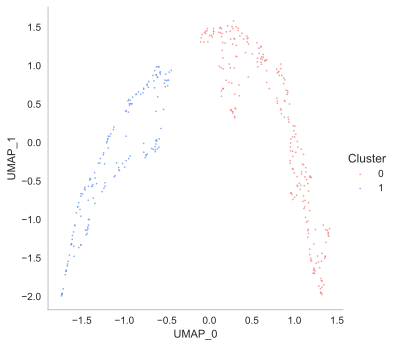

In [19]:
umap_cluster_list_dbscan,umap_cluster_counts_dbscan=umap_clustering.DBSCAN(0.5,20)

In [20]:
#Remove ruído
non_noise_indices= np.where(np.array(umap_cluster_list_dbscan)!=-1)
umap_emb= umap_emb.iloc[non_noise_indices]
#FDC_emb_low= FDC_emb_low.iloc[non_noise_indices]
umap_cluster_list_dbscan= np.array(umap_cluster_list_dbscan)[non_noise_indices]

In [21]:
silhouette_score(umap_emb, umap_cluster_list_dbscan, metric='euclidean')

0.5032854083336068

In [22]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list_dbscan))

0.13629724205568197

Dividindo as variaveis
- cont_list = continuas
- ord_list = ordinais
-  nom_list  = nominais

In [23]:
cont_list=['Age']

ord_list=['Duration','Frequency','Intensity','Visual','Nausea', 'Vomit']

nom_list=['Location','Character','Dysphasia', 'Vertigo', 'Tinnitus','Sensory','Phonophobia','Photophobia', 'Hypoacusis', 'Diplopia', 'Defect','Conscience', 'Paresthesia', 'DPF']

In [24]:
len(ord_list)

6

In [25]:
len(nom_list)

14

In [26]:
len(cont_list)

1

FDC nos dados originais

In [27]:
from fdc.fdc import FDC, Clustering
from fdc.fdc import canberra_modified
modified_can = canberra_modified

FDC.normalize (init): 0.00000 / 0.000s
FDC.normalize (clustering CONT): 0.95312 / 0.953s
FDC.normalize (clustering ORD): 1.07812 / 2.031s
FDC.normalize (clustering NOM): 1.31250 / 3.344s
FDC.normalize (concat): 0.00000 / 3.344s
FDC.normalize (umap 5 -> 2): 0.37500 / 3.719s
FDC.normalize (array -> DataFrame): 0.00000 / 3.719s


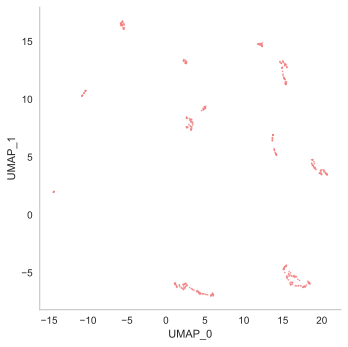

FDC.normalize (plotting): 0.35938 / 4.078s
FDC.normalize (array -> DataFrame): 0.00000 / 4.078s
FDC.normalize (total): 0.00000 / 4.078s


In [28]:
fdc = FDC(clustering_cont=Clustering('euclidean',15,0.1,max_components=1)
          , clustering_ord=Clustering(modified_can,15,0.1)
          , clustering_nom=Clustering('hamming',15,0.1)
          , visual=True
          , use_pandas_output=True
          , with_2d_embedding=True
          )

fdc.selectFeatures(continueous=cont_list, nomial=nom_list, ordinal=ord_list)

FDC_emb_high,FDC_emb_low = fdc.normalize(data,n_neighbors=15, min_dist=0.1,cont_list=cont_list, nom_list=nom_list, ord_list=ord_list,
                  with_2d_embedding=True,
                  visual=True)

Silhouette_score e Dunn index para os clusters FDC (de dimensão intermediaria) extraídos usando k-means

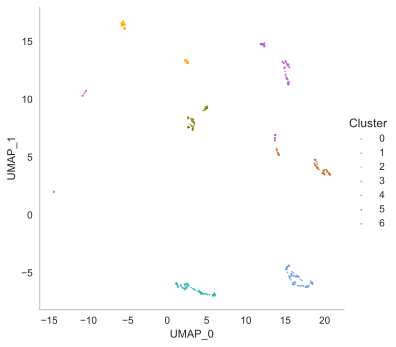

In [29]:
from fdc.clustering import Clustering

clustering=Clustering(FDC_emb_high,FDC_emb_low,True)
cluster_list,cluster_counts=clustering.K_means(7)

In [30]:
FDC_emb_high['Cluster'] = cluster_list

In [31]:
silhouette_score(FDC_emb_high, cluster_list, metric='euclidean')

0.5263088504956217

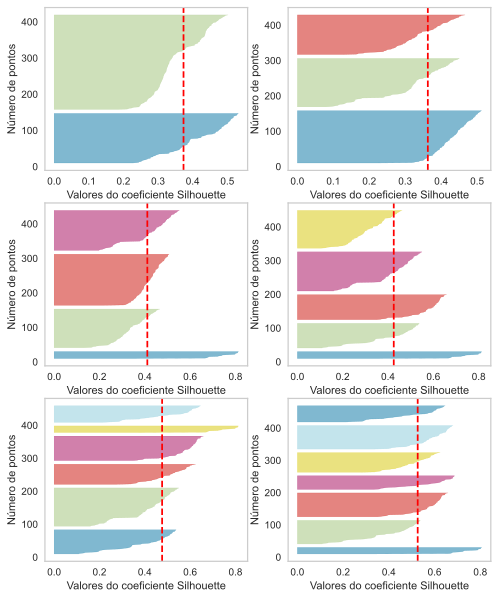

In [32]:
Silhouette_visual(FDC_emb_high)

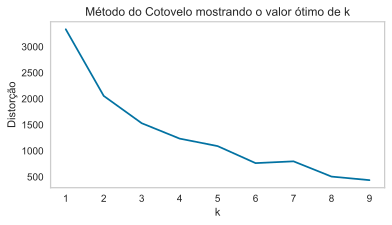

In [33]:
elbow_plot(FDC_emb_high)

In [34]:
dunn_index(cluster_wise_df(FDC_emb_high,cluster_list))

0.34635108997399316

Silhouette_score e Dunn index para os clusters FDC (de dimensão intermediaria) extraídos usando clustering aglomerativo

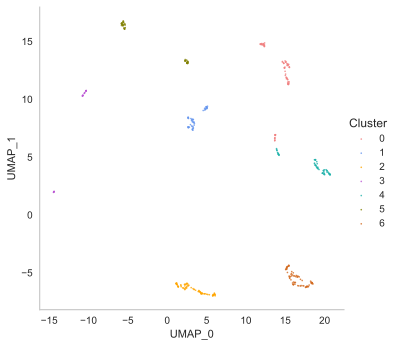

In [36]:
cluster_list_agglo,cluster_counts_agglo=clustering.Agglomerative(7,'euclidean','ward')

In [37]:
FDC_emb_high['Cluster'] = cluster_list_agglo

In [38]:
silhouette_score(FDC_emb_high, cluster_list_agglo, metric='euclidean')

0.5453826258095558

In [39]:
dunn_index(cluster_wise_df(FDC_emb_high,cluster_list_agglo))

0.44912766339022886

Silhouette_score e Dunn index para os clusters FDC (de dimensão intermediaria) extraídos usando clustering do DBSCAN

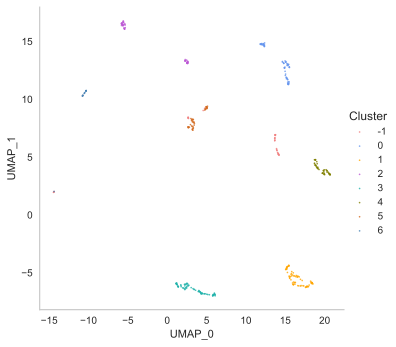

In [40]:
cluster_list_dbscan,cluster_counts_dbscan=clustering.DBSCAN(1.5,15)

In [41]:
cluster_counts_dbscan

array([38, 62, 74, 43, 75, 49, 44, 15])

In [42]:
FDC_emb_high['Cluster'] = cluster_list_dbscan

In [43]:
#Remove ruído
non_noise_indices= np.where(np.array(cluster_list)!=-1)
FDC_emb_high= FDC_emb_high.iloc[non_noise_indices]
FDC_emb_low= FDC_emb_low.iloc[non_noise_indices]
cluster_list= np.array(cluster_list)[non_noise_indices]

In [44]:
silhouette_score(FDC_emb_high, cluster_list_dbscan, metric='euclidean')

0.5196772423716243

In [45]:
dunn_index(cluster_wise_df(FDC_emb_high,cluster_list_dbscan))

0.4512104468312087